<a href="https://colab.research.google.com/github/wtryab-re/whats-your-eda/blob/main/multivariate_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pairplot, corr heatmap, cluster map, interaction and subgroup pattern discovery

#Install and Imports

In [ ]:
!pip install -q pandas numpy seaborn matplotlib

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_style("whitegrid")

Dataset Import

In [ ]:
df = sns.load_dataset("titanic")
df.sample(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
130,0,3,male,33.00,0,0,7.90,C,Third,man,True,NaN,Cherbourg,no,True
237,1,2,female,8.00,0,2,26.25,S,Second,child,False,NaN,Southampton,yes,False
790,0,3,male,NaN,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [ ]:
df.shape

(891, 15)

In [ ]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


In [ ]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
df["survived_label"] = df["survived"].map({1: "Yes", 0: "No"})
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,survived_label
0,0,3,male,22.00,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False,No
1,1,1,female,38.00,1,0,71.28,C,First,woman,False,C,Cherbourg,yes,False,Yes
2,1,3,female,26.00,0,0,7.92,S,Third,woman,False,NaN,Southampton,yes,True,Yes
3,1,1,female,35.00,1,0,53.10,S,First,woman,False,C,Southampton,yes,False,Yes
4,0,3,male,35.00,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True,No


In [ ]:
numeric_cols = ["sibsp", "parch", "fare", "age"]

In [ ]:
categorical_cols = list(df.columns)
for col in numeric_cols:
  categorical_cols.remove(col)
categorical_cols

['survived',
 'pclass',
 'sex',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone',
 'survived_label']

#Pairplot

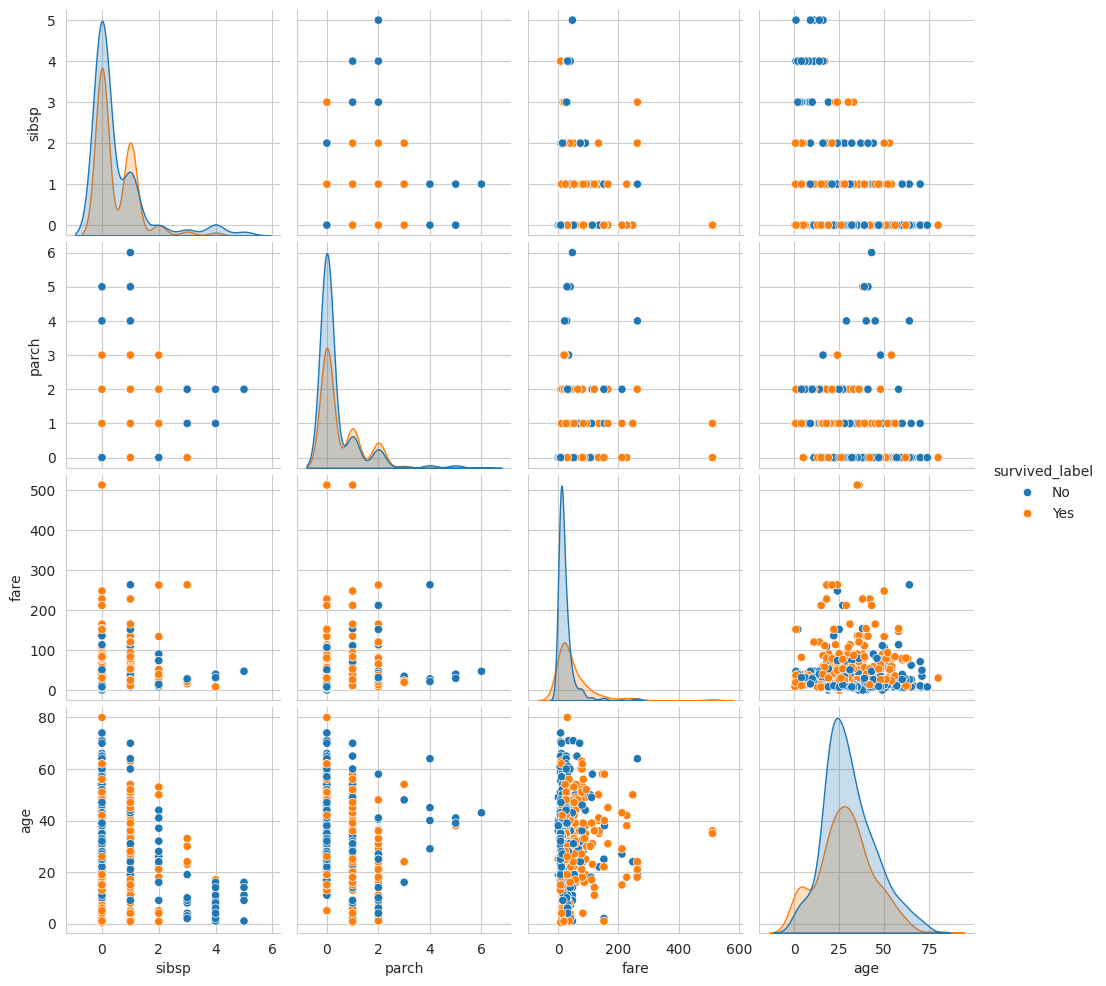

In [ ]:
pairplot_cols = numeric_cols + ["survived_label"]
sns.pairplot(data=df[pairplot_cols].dropna(), hue="survived_label")

In [ ]:
df[numeric_cols].corr()

,sibsp,parch,fare,age
sibsp,1.00,0.41,0.16,-0.31
parch,0.41,1.00,0.22,-0.19
fare,0.16,0.22,1.00,0.10
age,-0.31,-0.19,0.10,1.00


<Axes: xlabel='fare', ylabel='age'>

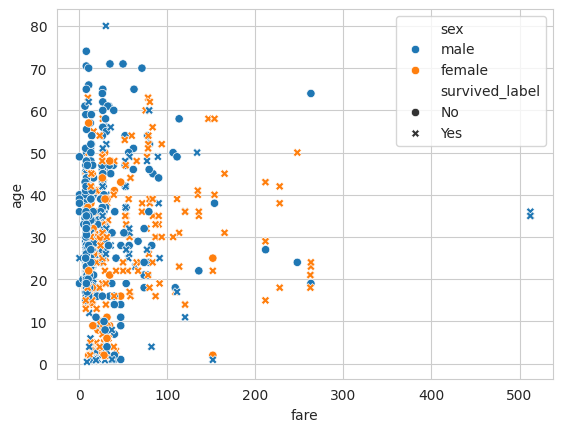

In [ ]:
sns.scatterplot(x="fare", y="age", data=df, hue="sex", style="survived_label")

#Heatmap

<Axes: >

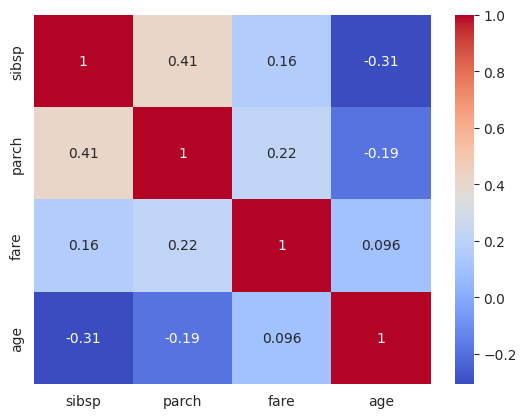

In [ ]:
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")

#Clustermap

<Figure size 400x400 with 0 Axes>

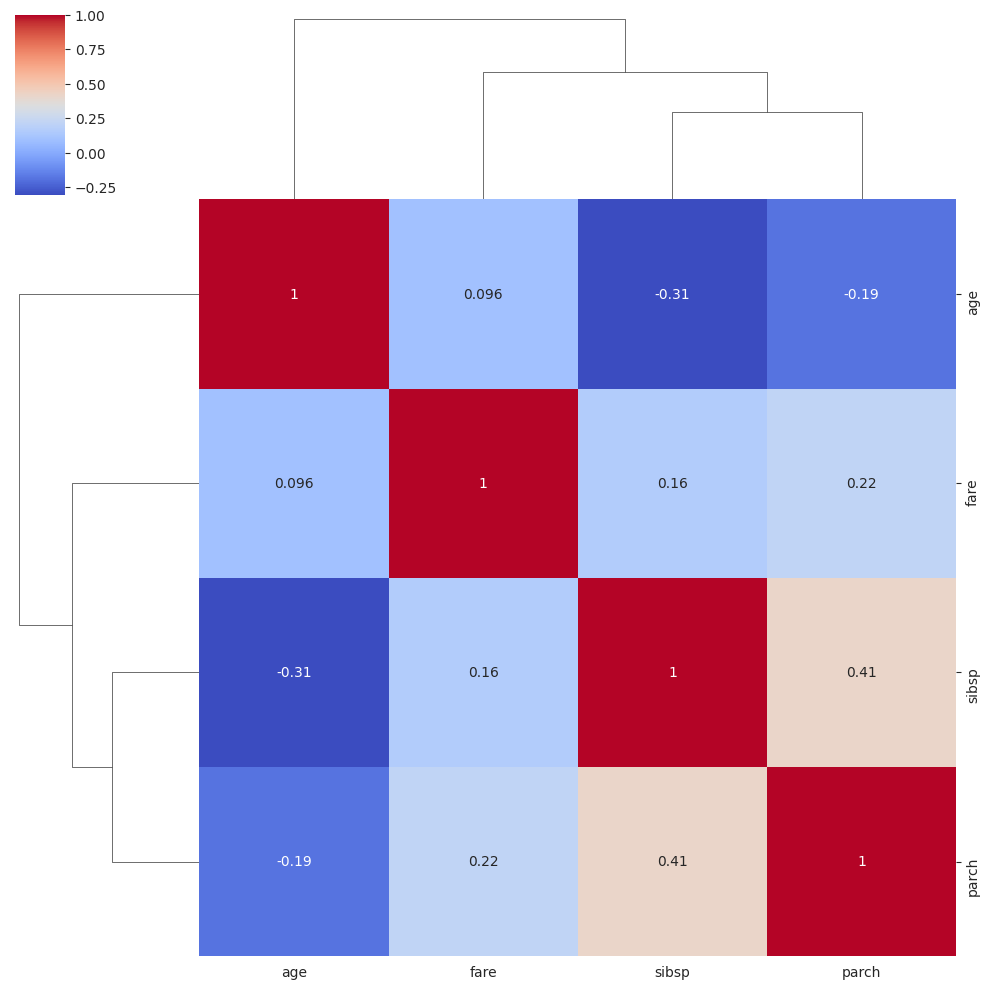

In [ ]:
plt.figure(figsize=(4,4))
sns.clustermap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

#Interaction and Subgroup Patterns

<Axes: xlabel='age', ylabel='fare'>

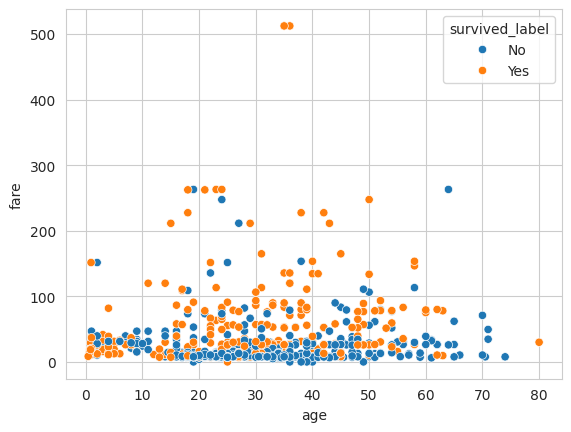

In [ ]:
sns.scatterplot(x="age", y="fare", data=df, hue="survived_label")